# Problem: Adversarial Attacks

If you encounter the following error while running the notebook:

```text
Running cells with '.venv (Python 3.12.12)' requires the ipykernel package.
Install 'ipykernel' into the Python environment. 
```

Please run the following command in your terminal:
```bash
pip install -i https://mirror-pypi.runflare.com/simple ipykernel
```

## **<span style="color:orange">Importing Libraries, Declaring Constants, Setting Seed & DEVICE </span>**


Installation

In [22]:
%pip install -i https://mirror-pypi.runflare.com/simple torch torchvision matplotlib tqdm numpy

Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


To load the downloaded weights, you'll need the `pytorch_cifar_models` package. Please ensure that you place the downloaded `pytorch_cifar_models` folder (from elearn) in the same directory as your code.

Alternatively, you can clone the repository directly by running the following command in your terminal:
```bash
!git clone https://github.com/chenyaofo/pytorch-cifar-models.git


In [23]:
import sys
sys.path.append("pytorch-cifar-models")

import pytorch_cifar_models as pcm

Library

In [24]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F

Set DEVICE

In [25]:
DEVICE = "cpu"
# if torch.backends.mps.is_available():
#     DEVICE = "mps"
# elif torch.cuda.is_available():
#     DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: cpu


Constants

In [26]:
BATCH_SIZE = 4

In [27]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [28]:
CIFAR10_DIR = "./cifar10_correct_samples"
RESENET20_WEIGHTS = "./cifar10_resnet20-4118986f.pt"

In [87]:
EPSILON = 0.03
ALPHA = 0.005

## **<span style="color:orange">Load Model & Data</span>**

Load model

In [30]:
model = pcm.cifar10_resnet20(pretrained=False)

In [31]:
state_dict = torch.load(RESENET20_WEIGHTS, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
model.to(DEVICE)

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Load image

In [ ]:
class CIFARCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.files = [
            f for f in os.listdir(root_dir)
            if f.endswith(".png")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.root_dir, filename)

        # load image
        image = Image.open(path).convert("RGB")

        # parse label from filename: "..._true3.png"
        label_str = filename.split("_true")[1].split(".png")[0]
        label = int(label_str)

        if self.transform:
            image = self.transform(image)

        return image, label

In [33]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.flatten().tolist(),
                        std=std.flatten().tolist())
])

dataset = CIFARCustomDataset(
    root_dir=CIFAR10_DIR,
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [34]:
print(f"Number of images: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Number of images: 25
Number of batches: 7


Check Model and Dataset Load

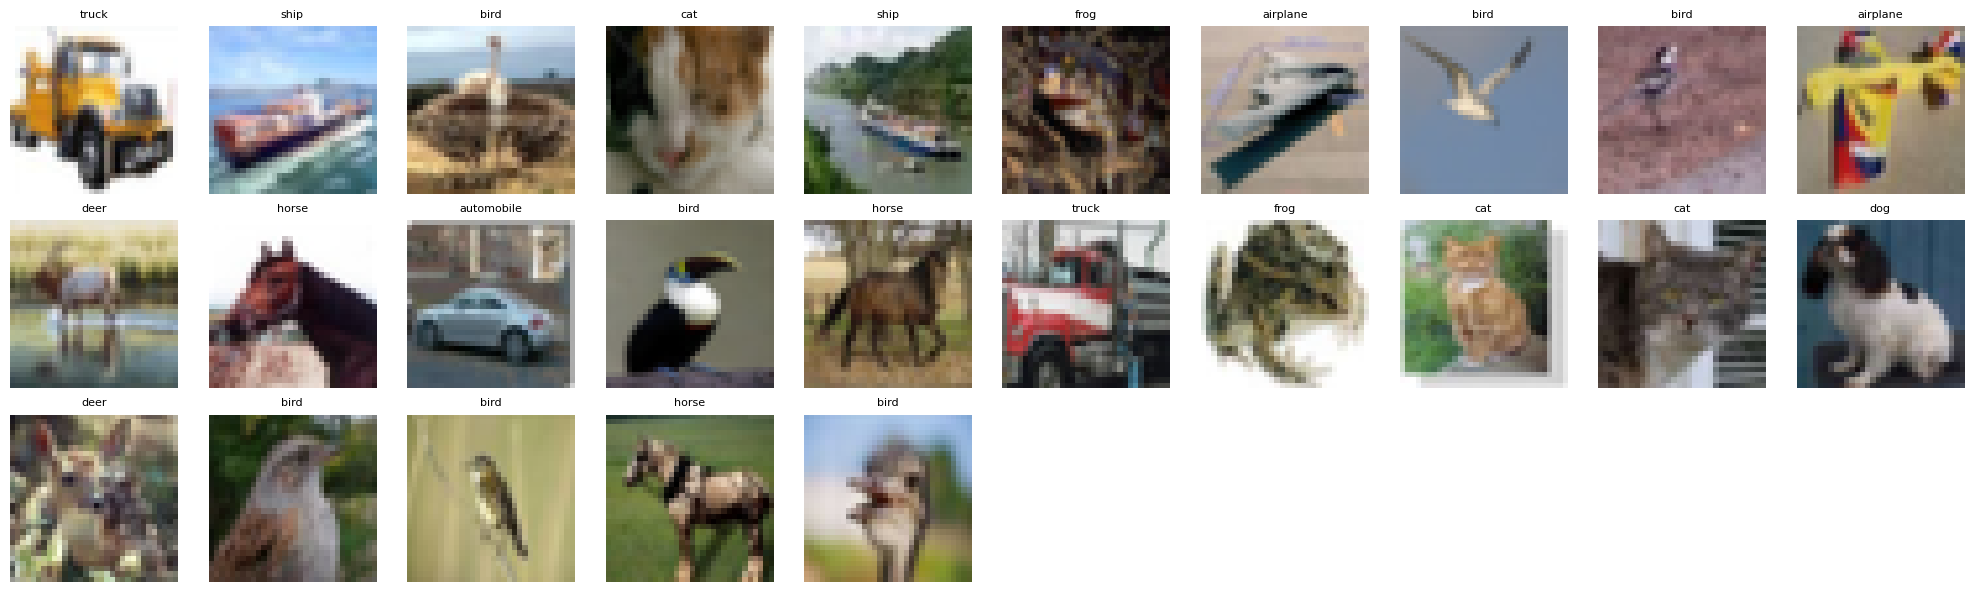

In [35]:
num_images = len(dataset)
cols = 10
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    img, true_lbl = dataset[i]
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{CIFAR10_CLASSES[true_lbl]}", fontsize=8)
    axes[i].axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [36]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [37]:
accuracy_clean_data = evaluate(model, dataloader)
print(f"Accuracy of the model on the {len(dataset)} clean images: {accuracy_clean_data:.4f}")

100%|██████████| 7/7 [00:00<00:00, 124.99it/s]

Accuracy of the model on the 25 clean images: 1.0000


## **<span style="color:orange">Attacks</span>**

***<span style="color:purple">FGSM</span>***

In [79]:
def fgsm_untargeted_attack(model, epsilon, images, labels):
    images = images.clone().detach().to(DEVICE)
    labels = labels.to(DEVICE)
    images.requires_grad = True
    model_output = model(images)
    loss = F.cross_entropy(model_output, labels)
    model.zero_grad()
    loss.backward()
    gradient = images.grad.data
    adversarial_images = images + (epsilon * gradient.sign())
    return adversarial_images.detach()

In [80]:
def evaluate_fgsm(model, dataloader, epsilon):
    model.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(dataloader):
        adversarial_images = fgsm_untargeted_attack(model, epsilon, images, labels)
        with torch.no_grad():
            model_output = model(adversarial_images)
            _ , predicted = torch.max(model_output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [81]:
fgsm_accuracy = evaluate_fgsm(model, dataloader, EPSILON)
print(f"FGSM untargeted accuracy: {fgsm_accuracy:.4f}")

100%|██████████| 7/7 [00:00<00:00, 55.10it/s]

FGSM untargeted accuracy: 0.2800


In [93]:
def visualize_results(model, dataloader, attack_method, attack_parameters):
    model.eval()
    samples = []
    for images, labels in dataloader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        adversarial_images = attack_method(model, **attack_parameters, images = images, labels = labels)  
        with torch.no_grad():
            model_output = model(adversarial_images)
            _, predicted = torch.max(model_output, 1)
        for i in range(len(labels)):
            if predicted[i] != labels[i] and len(samples) < 4:
                samples.append({
                    'original': images[i].cpu(),
                    'adversary': adversarial_images[i].cpu(),
                    'true label': labels[i].item(),
                    'prediction': predicted[i].item()
                })

    fig, axes = plt.subplots(4, 3, figsize=(10, 12))
    for i, s in enumerate(samples):
        original_image = (s['original'] * std.cpu() + mean.cpu()).permute(1, 2, 0).numpy()
        adversarial_images = (s['adversary'] * std.cpu() + mean.cpu()).permute(1, 2, 0).numpy()
        noise = (adversarial_images - original_image)
        noise = (noise - noise.min()) / (noise.max() - noise.min())
        axes[i, 0].imshow(np.clip(original_image, 0, 1))
        axes[i, 0].set_title(f"Original: {CIFAR10_CLASSES[s['true label']]}")
        axes[i, 1].imshow(noise)
        axes[i, 1].set_title("Adversarial Noise")
        axes[i, 2].imshow(np.clip(adversarial_images, 0, 1))
        axes[i, 2].set_title(f"Adversary: {CIFAR10_CLASSES[s['prediction']]}")
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.show()

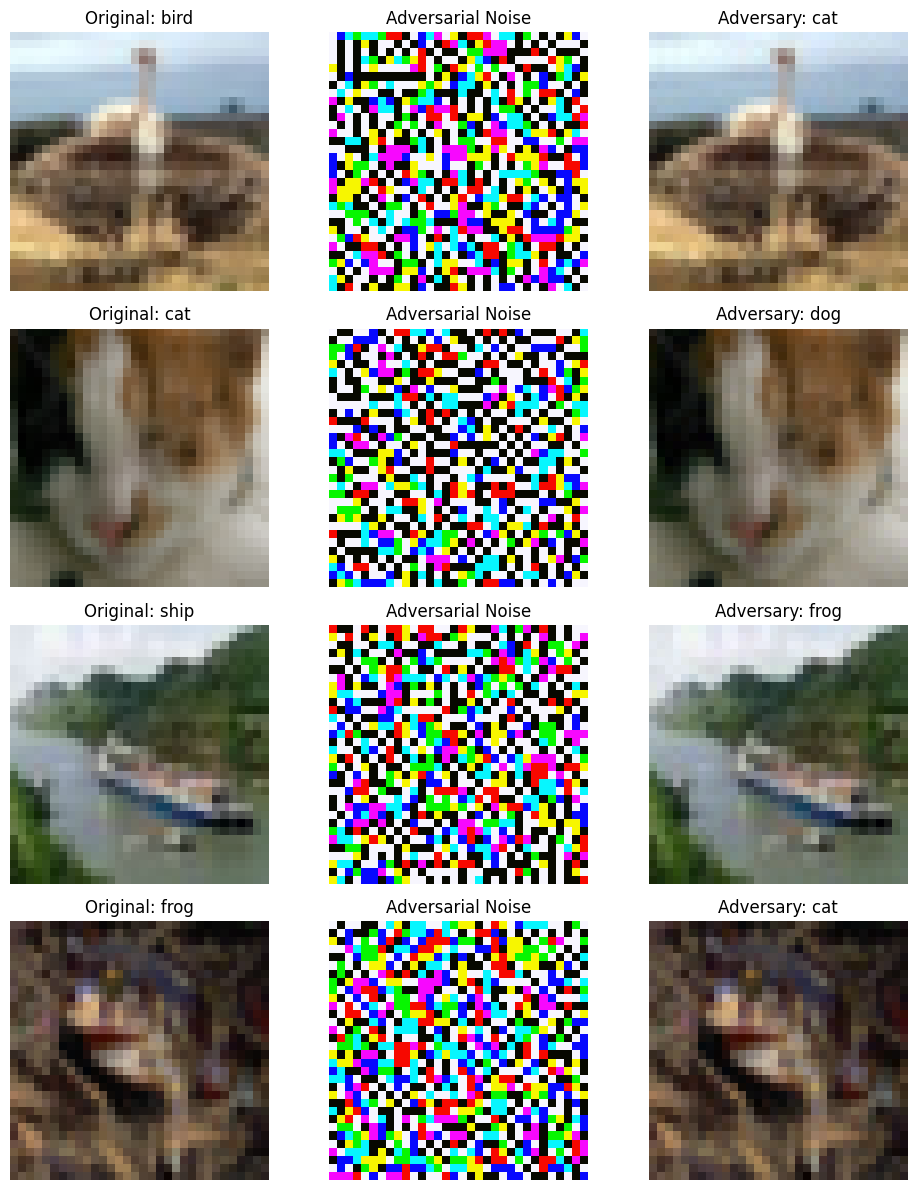

In [95]:
visualize_results(model, dataloader, attack_method=fgsm_untargeted_attack,attack_parameters={"epsilon": EPSILON})


***<span style="color:purple">PGD</span>***

In [90]:
def pgd_untargeted_attack(model, epsilon, alpha, images, labels):
    T = min(int(epsilon / alpha), 20)
    images = images.clone().detach().to(DEVICE)
    original_images = images.clone().detach()
    labels = labels.to(DEVICE)
    x_t = images.clone().detach()
    x_t.requires_grad = True
    for t in range(T):
        model_output = model(x_t)
        loss = F.cross_entropy(model_output, labels)
        model.zero_grad()
        loss.backward()
        gradient = x_t.grad.data
        x_t = x_t + (alpha * gradient.sign())
        delta = x_t - original_images
        delta = torch.clamp(delta, -epsilon, +epsilon)
        x_t = original_images + delta
        x_unnormal = x_t * std + mean
        x_unnormal = torch.clamp(x_unnormal, 0, 1)
        x_t = (x_unnormal - mean) / std
        x_t = x_t.clone().detach()
        x_t.requires_grad = True
    return x_t.detach()

In [91]:
def evaluate_pgd(model, dataloader, epsilon, alpha):
    model.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(dataloader):
        adversarial_images = pgd_untargeted_attack(model, epsilon, alpha, images, labels)
        with torch.no_grad():
            model_output = model(adversarial_images)
            _ , predicted = torch.max(model_output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [97]:
pgd_accuracy = evaluate_pgd(model, dataloader, EPSILON, ALPHA)
print(f"PGD untargeted accuracy: {pgd_accuracy:.4f}")

100%|██████████| 7/7 [00:00<00:00, 10.85it/s]

PGD untargeted accuracy: 0.1200


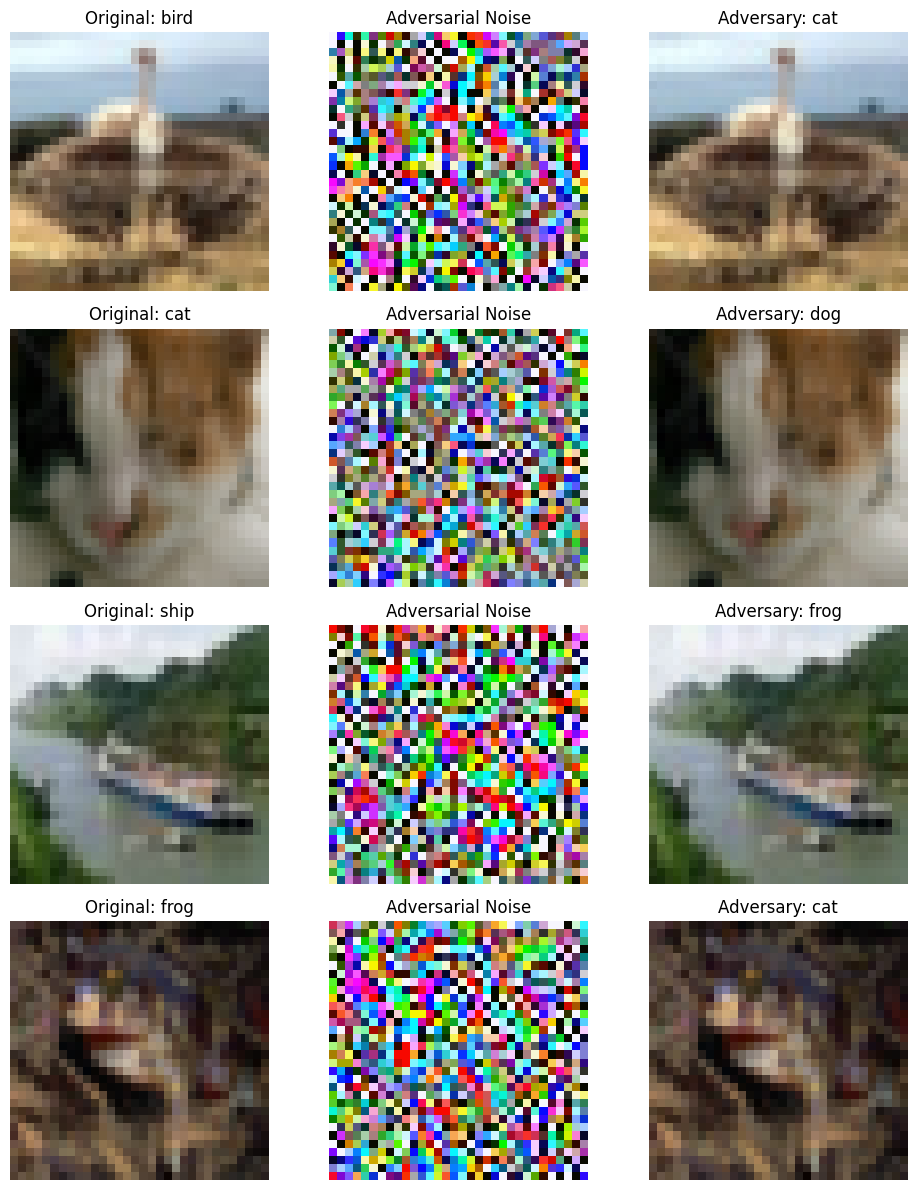

In [96]:
visualize_results(model, dataloader, attack_method=pgd_untargeted_attack,attack_parameters={"epsilon": EPSILON, "alpha": ALPHA})